<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/Oppgave4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

h = 0.01980198019801982
dt = 0.00015684736790510764
r = 0.4000000000000001


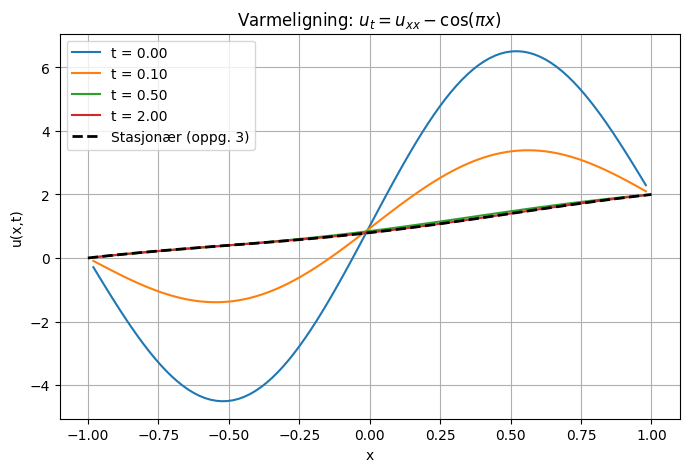

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# OPPGAVE 4: Varmeligning 1D
# u_t = u_xx - cos(pi*x),  t >= 0, -1 < x < 1
# Initialbetingelse:  u(x, 0) = 1 + x + 5*sin(pi*x)
# Randbetingelser:    u(-1, t) = 0   og   u(1, t) = 2

# --- Romgitter ---
m = 100
x = np.linspace(-1, 1, m + 2)
h = x[1] - x[0]

# Bygg matrise L og kildeledd f(x) = cos(pi*x)
L = (1 / h**2) * (
    np.diag((m - 1) * [1], -1) +
    np.diag(m * [-2], 0) +
    np.diag((m - 1) * [1], 1)
)
f = np.cos(np.pi * x[1:-1])

# --- Fysiske parametere og randbetingelser ---
c = 1
a = 0   # u(-1) = a
B = 2   # u( 1) = B

A = (c**2) * L    # u_t = c^2*u_xx - f

# --- Høyreside og randbidrag ---
F = f.copy()
F[0]  -= (c**2) * a / h**2
F[-1] -= (c**2) * B / h**2

# --- Tid og stabilitet ---
T = 2.0
dt = 0.4 * h**2
N = int(T / dt) + 1

print("h =", h)
print("dt =", dt)
print("r =", c**2 * dt / h**2)

# --- Forlengs Euler-funksjon ---
def euler(g, x0, t0, t1, N):
    t = np.linspace(t0, t1, N)
    dt = t[1] - t[0]
    out = np.zeros((N, x0.size))
    out[0, :] = x0
    for n in range(N - 1):
        out[n + 1, :] = out[n, :] + dt * g(out[n, :], t[n])
    return out, t

# --- Høyreside for ODE ---
def g(u, t):
    return A @ u - F

# --- Initialbetingelse ---
u0 = 1.0 + x[1:-1] + 5 * np.sin(np.pi * x[1:-1])

# --- Kjør Euler ---
u_varme, t = euler(g, u0, 0, T, N)

# --- Indekser for plotting ---
idx1 = N // 20
idx2 = N // 4
idx3 = N - 1

# --- Stasjonær løsning (fra oppgave 3) ---
def u_stasjonaer(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(x[1:-1], u_varme[0,    :], label=f"t = {t[0]:.2f}")
plt.plot(x[1:-1], u_varme[idx1, :], label=f"t = {t[idx1]:.2f}")
plt.plot(x[1:-1], u_varme[idx2, :], label=f"t = {t[idx2]:.2f}")
plt.plot(x[1:-1], u_varme[idx3, :], label=f"t = {t[idx3]:.2f}")
plt.plot(x,       u_stasjonaer(x),  "k--", linewidth=2, label="Stasjonær (oppg. 3)")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(r"Varmeligning: $u_t = u_{xx} - \cos(\pi x)$")
plt.legend()
plt.grid(True)
plt.show()